In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

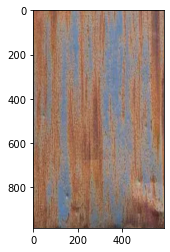

In [49]:
source_img = cv2.imread("C:\\Users\\86994\\Desktop\\13.png") # 读入图片
plt.imshow(cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB))
plt.show()

In [50]:
data_img = source_img.reshape(-1,3)

In [ ]:
_sub_data = data_img[0:1000]
fig = plt.figure(figsize=(15,15))#创建图片
subplot = fig.add_subplot(111, projection='3d')#确定函数图像位置，并标注绘制的是3D图（projection）
# Customize the z axis
subplot.set_xlim(0, 256)
subplot.set_ylim(0, 256)
subplot.set_zlim(0, 256)
sca = subplot.scatter(_sub_data[:,0],_sub_data[:,1],_sub_data[:,2])
plt.show()


In [51]:
data_img_copy = data_img.astype(np.float32)/255. # 转为32位的浮点数便于处理

In [68]:
color_group = []
color_group_mask = []
dis = 3.0/10

temp_mask = np.ones(shape=(data_img_copy.shape[0]),dtype=np.uint8)
temp_mask = temp_mask==1 # 参与计算的点的掩膜
static_temp_mask = temp_mask==0 # 单独一个颜色的掩膜

In [69]:
_t1 = time.time()
while np.count_nonzero(temp_mask)!=0:
    _center_point = (data_img_copy[temp_mask])[0]
    color_group.append(_center_point )  # 中心点放入列表
    _dis_vec = data_img_copy - _center_point
    _dis_vec_pow = np.power(_dis_vec, 2)
    _dis_vec_pow_sum = np.sum(_dis_vec_pow, axis=1)
    _mask = _dis_vec_pow_sum>=dis

    temp_mask = temp_mask & _mask # 半径平方大于0.4的点保留
    color_group_mask.append(static_temp_mask | _mask==False) # 掩膜也添加进去
    # print(_mask.shape)
    print("count -----------------")
print(time.time()-_t1)

count -----------------
count -----------------
0.1788623332977295


In [70]:
color_group_np = np.array(color_group) * 255 # 分离出的颜色组
color_group_np = color_group_np.astype(np.uint8)

In [23]:
dst_data_img = np.zeros_like(data_img, dtype=np.uint8)
# for color, mask in zip(color_group_np, color_group_mask):
#     dst_data_img[mask] = color

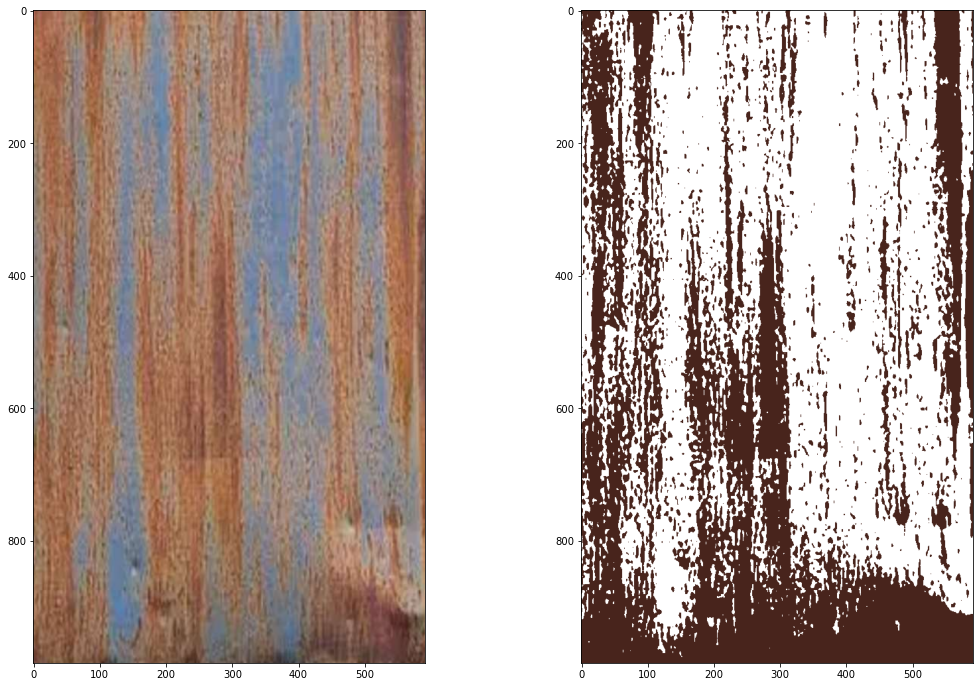

In [72]:
dst_data_img = np.ones_like(data_img, dtype=np.uint8) * 255
_index = 1
dst_data_img[color_group_mask[_index]] = color_group_np[_index]
dst_data_img = dst_data_img.reshape(source_img.shape)


plt.figure(figsize=(18,12))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(dst_data_img, cv2.COLOR_BGR2RGB))
plt.show()

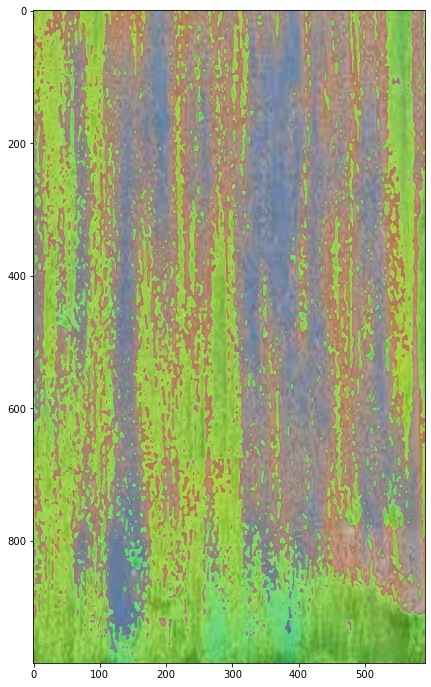

In [74]:
_mask_img = np.full_like(data_img, [0,255,0], dtype=np.uint8)
_mask_img[color_group_mask[_index]==False] = np.array([0,0,0])
_mask_img = _mask_img.astype(np.float32) / 255.
_mask_img = _mask_img.reshape(source_img.shape)
_result = source_img.astype(np.float32)/255. + 0.4*_mask_img
plt.figure(figsize=(18,12))
plt.subplot(1,1,1)
plt.imshow(cv2.cvtColor(_result, cv2.COLOR_BGR2RGB))

In [12]:
dst_data_img = dst_data_img.reshape(source_img.shape)

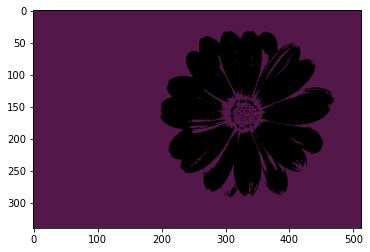

In [13]:
plt.imshow(cv2.cvtColor(dst_data_img, cv2.COLOR_BGR2RGB))
plt.show()